# Predicting the Results of Professional Tennis Matches with Machine Learning 

## 1. Setup

### Required libraries

In [ ]:
%pip install -q pandas matplotlib numpy scikit-learn xgboost catboost shap

### Library imports

In [511]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from catboost import CatBoostClassifier
from pathlib import Path
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, f1_score, log_loss, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, HalvingGridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

### Configuration

In [450]:
# Dataset file
DATA_DIR = Path.cwd().parent / "data"
DATA_FILE = DATA_DIR / "atp_matches.csv"

# Random state for reproducibility
RANDOM_STATE = 42

# Target feature
TARGET_FEATURE = "winner"

# Present on the dataframe but ignored by classifiers
METADATA_FEATURES = {
    "tournament_id",
    "tournament_start_date",
    "tournament_name",
    "match_num",
    "player1_id",
    "player2_id",
    "player1_name",
    "player2_name",
    "score",
}

# Force certain numeric features to be treated as categorical
AS_CATEGORICAL = {
    "best_of",
}

# Features that, if missing, means rows will be dropped
DROP_MISSING_FEATURES = {
    # "player1_rank",
    # "player2_rank",
    # "player1_points",
    # "player2_points",
}

# Features to completely drop from the dataset (useful for testing)
DROP_FEATURES = {
    # "player1_points",
    # "player2_points",
}

# Testing and trainingparameters
TRAIN_RATIO = 0.8
TEST_RATIO = 1 - TRAIN_RATIO
NUM_CV_SPLITS = 5

### Helpers

In [276]:
TOURNAMENT_LEVEL_LABELS = {
    "A": "ATP 250 and 500",
    "D": "Davis Cup",
    "F": "ATP Finals",
    "G": "Grand Slam",
    "M": "Masters 1000",
    "N": "Next Gen Finals",
    "O": "Olympics",
}

## 2. Data Loading

In [451]:
if DATA_FILE.is_file():
    raw_df = pd.read_csv(DATA_FILE)
else:
    raise FileNotFoundError(
        "Failed to find or read dataset file."
    )

(num_rows, num_cols) = raw_df.shape
print(f"Dataset has {num_rows:,} rows and {num_cols} columns.")

Dataset has 189,373 rows and 63 columns.


## 3. Data Exploration

### Distribution of matches where the winner is player1

In [452]:
# winner == 1 means player1 won; winner == 2 means player2 won
player1_wins = (raw_df[TARGET_FEATURE] == 1).sum()
n_matches = len(raw_df)
pct_player1 = 100 * player1_wins / n_matches

print(
    f"Player1 win rate: {pct_player1:.2f}% "
    f"({player1_wins:,} of {n_matches:,} matches)"
)

Player1 win rate: 50.06% (94,801 of 189,373 matches)


### Matches per year by tournament level

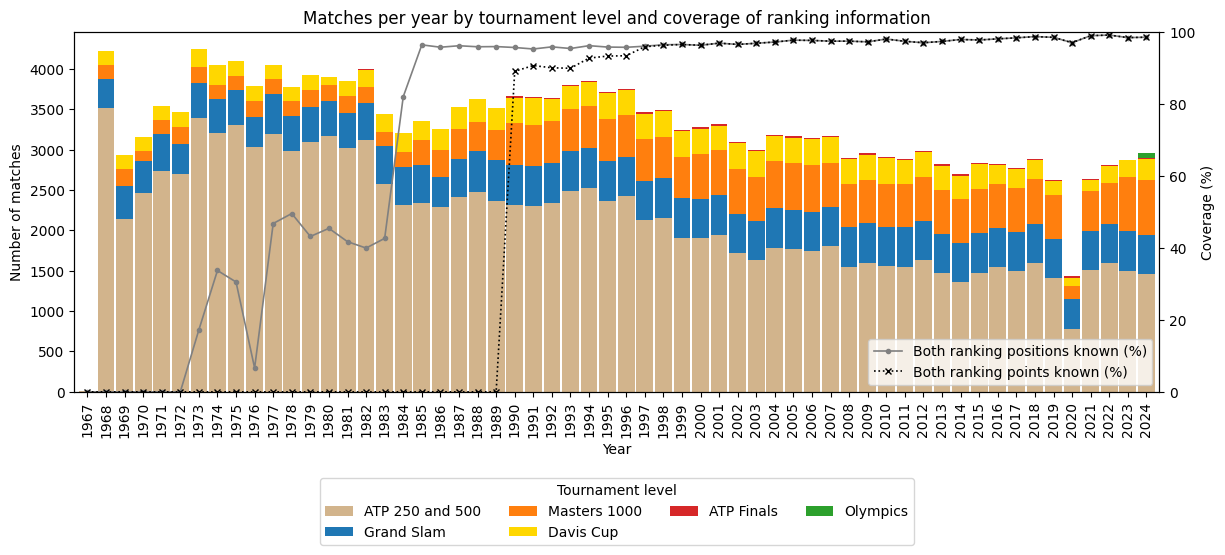

In [453]:
counts_by_year_level = (
    raw_df.groupby(["year", "tournament_level"], observed=True)
    .size()
    .unstack(fill_value=0)
)

# Stack order: most common levels at the bottom of the stack
level_order = counts_by_year_level.sum().sort_values(ascending=False).index
counts_by_year_level = counts_by_year_level.reindex(columns=level_order, fill_value=0)
counts_by_year_level = counts_by_year_level.rename(
    columns=lambda c: TOURNAMENT_LEVEL_LABELS.get(str(c), str(c))
)

# Rank/points coverage by year (share of matches where both players have values)
coverage_by_year = raw_df.groupby("year", observed=True).apply(
    lambda g: pd.Series(
        {
            "pct_both_ranks": (
                g["player1_rank"].notna() & g["player2_rank"].notna()
            ).mean()
            * 100,
            "pct_both_points": (
                g["player1_points"].notna() & g["player2_points"].notna()
            ).mean()
            * 100,
        }
    ),
    include_groups=False
)

fig, ax = plt.subplots(figsize=(14, 6))

# Color mapping (requested): ATP 250/500 = yellow, Grand Slam = blue, Davis Cup = orange
_level_colors = {
    "ATP 250 and 500": "tan",
    "Davis Cup": "gold",
    "ATP Finals": "tab:red",
    "Grand Slam": "tab:blue",
    "Masters 1000": "tab:orange",
    "Next Gen Finals": "black",
    "Olympics": "tab:green",
}
colors = [_level_colors.get(c, None) for c in counts_by_year_level.columns]

counts_by_year_level.plot(
    ax=ax,
    kind="bar",
    stacked=True,
    width=0.9,
    color=colors,
)

# Overlay coverage lines on secondary axis.
# Note: pandas bar plots use x = 0..N-1 (not the year values), so we align to those positions.
years = counts_by_year_level.index
coverage_aligned = coverage_by_year.reindex(years)
x = np.arange(len(years))

ax2 = ax.twinx()
ax2.plot(
    x,
    coverage_aligned["pct_both_ranks"],
    color="gray",
    linewidth=1.2,
    marker="o",
    markersize=3,
    label="Both ranking positions known (%)",
)
ax2.plot(
    x,
    coverage_aligned["pct_both_points"],
    color="black",
    linewidth=1.2,
    linestyle="dotted",
    marker="x",
    markersize=4.0,
    label="Both ranking points known (%)",
)
ax2.set_ylabel("Coverage (%)")
ax2.set_ylim(0, 100)
ax2.legend(loc="lower right")
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_title("Matches per year by tournament level and coverage of ranking information")
n_levels = counts_by_year_level.shape[1]
ax.legend(
    title="Tournament level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(n_levels, 4),
)
plt.xticks(rotation=45, ha="right")
fig.subplots_adjust(bottom=0.28)
plt.show()

### Rank coverage by month

Share of matches where both players have a known ATP ranking (`player1_rank` and `player2_rank` is not empty).

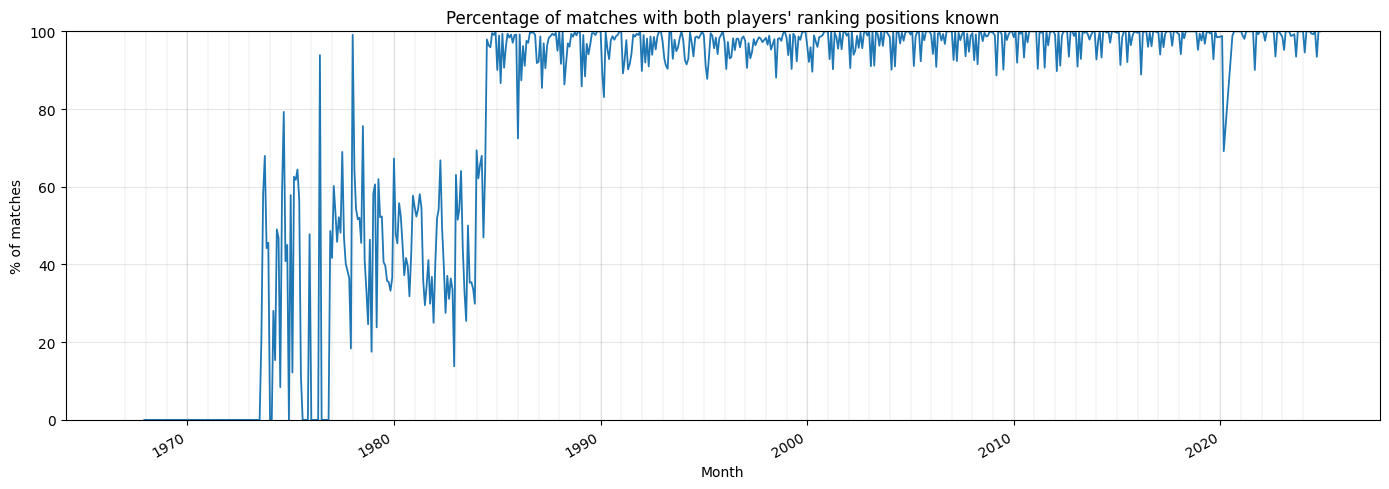

In [228]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
rank_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])
both_ranks_known = rank_df["player1_rank"].notna() & rank_df["player2_rank"].notna()
pct_both_ranks_by_month = (
    rank_df.assign(both_ranks_known=both_ranks_known)
    .groupby("month", observed=True)["both_ranks_known"]
    .mean()
    * 100
)

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_both_ranks_by_month.index.min().year
year_max = pct_both_ranks_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    pct_both_ranks_by_month.index.to_timestamp(),
    pct_both_ranks_by_month.values,
    linewidth=1.3,
    zorder=2,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title("Percentage of matches with both players' ranking positions known")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Matches per year by tournament level after dropping rows with missing features

Stacked bars match the earlier “matches per year by tournament level” figure, after rows with missing features were dropped.

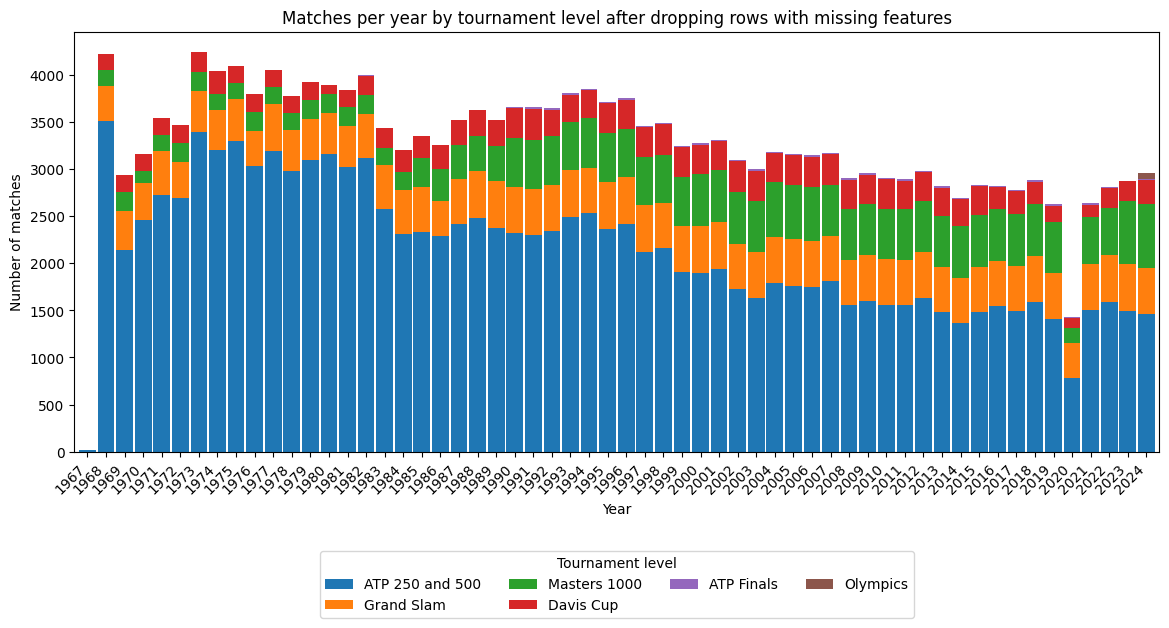

In [229]:
full_ranking_df = raw_df.dropna(
    subset=DROP_MISSING_FEATURES,
    how="any",
)

counts_by_year_level_full = (
    full_ranking_df.groupby(["year", "tournament_level"], observed=True)
    .size()
    .unstack(fill_value=0)
)

level_order = counts_by_year_level_full.sum().sort_values(ascending=False).index
counts_by_year_level_full = counts_by_year_level_full.reindex(
    columns=level_order, fill_value=0
)
counts_by_year_level_full = counts_by_year_level_full.rename(
    columns=lambda c: TOURNAMENT_LEVEL_LABELS.get(str(c), str(c))
)

fig, ax = plt.subplots(figsize=(14, 7))
counts_by_year_level_full.plot(ax=ax, kind="bar", stacked=True, width=0.9)
ax.set_xlabel("Year")
ax.set_ylabel("Number of matches")
ax.set_title(
    "Matches per year by tournament level after dropping rows with missing features"
)
n_levels = counts_by_year_level_full.shape[1]
ax.legend(
    title="Tournament level",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=min(n_levels, 4),
)
plt.xticks(rotation=45, ha="right")
fig.subplots_adjust(bottom=0.28)
plt.show()

### Favorite wins by month

Among matches where **both** `player1_rank` and `player2_rank` are known, the share of matches won by the **better-ranked** player (lower ATP rank number). Rows with **identical** ranks are excluded. Monthly percentage is over that filtered set only.

Overall: better-ranked player wins 66.24% of eligible matches (92,677 of 139,906).


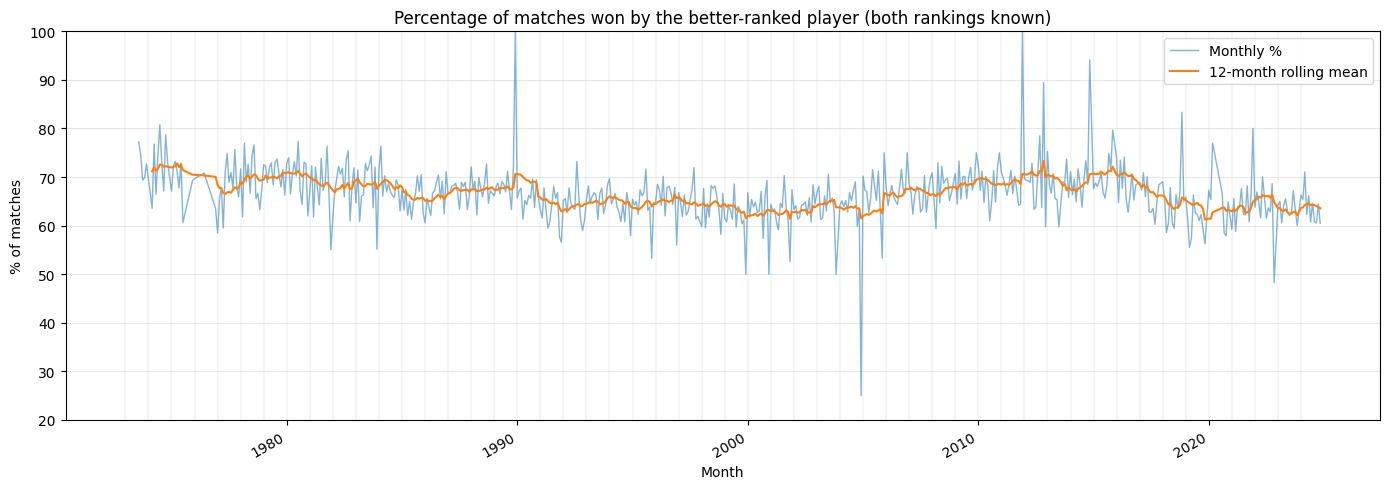

In [230]:
month_dt = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce")
fav_df = raw_df.assign(month=month_dt.dt.to_period("M")).dropna(subset=["month"])

both_ranks_known = fav_df["player1_rank"].notna() & fav_df["player2_rank"].notna()
fav_df = fav_df.loc[both_ranks_known]

# Drop ties — no unique "better-ranked" player (same rank on both sides)
fav_df = fav_df[fav_df["player1_rank"] != fav_df["player2_rank"]]

favorite_wins = (
    ((fav_df["player1_rank"] < fav_df["player2_rank"]) & (fav_df[TARGET_FEATURE] == 1))
    | ((fav_df["player2_rank"] < fav_df["player1_rank"]) & (fav_df[TARGET_FEATURE] == 2))
)

n_eligible = len(fav_df)
pct_favorite_overall = 100 * favorite_wins.mean()
print(
    f"Overall: better-ranked player wins {pct_favorite_overall:.2f}% of eligible matches "
    f"({int(favorite_wins.sum()):,} of {n_eligible:,})."
)

pct_favorite_by_month = (
    fav_df.assign(favorite_wins=favorite_wins)
    .groupby("month", observed=True)["favorite_wins"]
    .mean()
    * 100
)

ROLL_MONTHS = 12
running_avg = pct_favorite_by_month.rolling(window=ROLL_MONTHS, min_periods=6).mean()

ts = pct_favorite_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

year_min = pct_favorite_by_month.index.min().year
year_max = pct_favorite_by_month.index.max().year
for y in range(year_min, year_max + 1):
    ax.axvline(
        pd.Timestamp(year=y, month=1, day=1),
        color="#d8d8d8",
        linewidth=0.3,
        zorder=0,
    )

ax.plot(
    ts,
    pct_favorite_by_month.values,
    linewidth=1.0,
    alpha=0.55,
    label="Monthly %",
    zorder=2,
)
ax.plot(
    ts,
    running_avg.values,
    linewidth=1.5,
    label=f"{ROLL_MONTHS}-month rolling mean",
    zorder=3,
)
ax.set_xlabel("Month")
ax.set_ylabel("% of matches")
ax.set_title(
    "Percentage of matches won by the better-ranked player "
    "(both rankings known)"
)
ax.set_ylim(20, 100)
ax.set_yticks(np.arange(20, 101, 10))
ax.grid(True, alpha=0.3, axis="y", which="major")
ax.legend(loc="best")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Favorite agreement with outcome by year

For each calendar year, the chart shows the **percentage of matches** in which the **pre-match favorite** (by ATP ranking or by each overall rating) **won**. **Ranking:** lower rank number is better (when `player1_rank` is strictly lower than `player2_rank`, player 1 is the favorite). **Ratings:** higher value is better. Rows with **missing** values or a **tie** on the relevant pair of columns are excluded from that metric’s yearly percentage. Surface-specific ratings are not shown in the chart.

The **overall** favorite-win rates for the full dataset is also reported below the chart, and includes the surface-specific ratings.

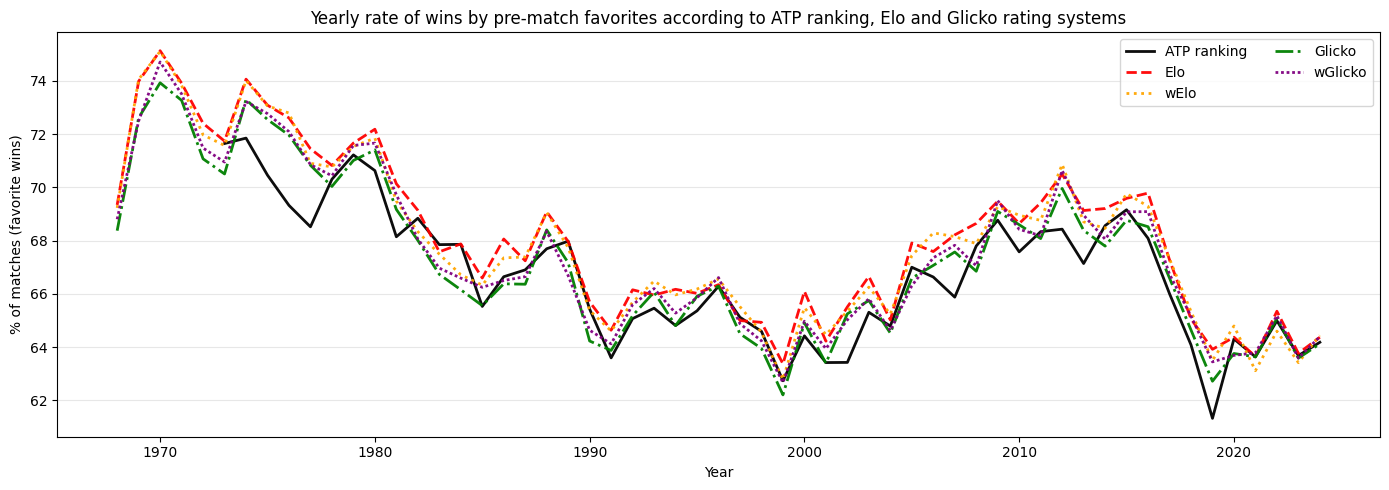


Overall favorite-win rate (both ATP ranks known; non-missing rating pair; ties excluded per metric):
  ATP ranking: 66.24%  (n = 139,906)
  Elo: 68.31%  (n = 188,680)
  wElo: 68.12%  (n = 188,753)
  Surface Elo: 67.45%  (n = 187,654)
  Surface wElo: 67.09%  (n = 187,844)
  Glicko: 67.48%  (n = 188,114)
  wGlicko: 67.73%  (n = 188,169)
  Surface Glicko: 66.57%  (n = 186,316)
  Surface wGlicko: 66.76%  (n = 186,494)


In [454]:
year_series = pd.to_datetime(raw_df["tournament_start_date"], errors="coerce").dt.year
plot_df = raw_df.assign(year=year_series).dropna(subset=["year"])
plot_df["year"] = plot_df["year"].astype(int)


def yearly_favorite_agreement_pct(df, col1, col2, *, lower_is_better: bool) -> pd.Series:
    """Per-year % of matches where the favorite (by col1 vs col2 ordering) won."""
    sub = df.dropna(subset=[col1, col2, TARGET_FEATURE, "year"]).copy()
    sub = sub[sub["year"] >= 1968]
    sub = sub[sub[col1] != sub[col2]]
    if lower_is_better:
        agree = (
            ((sub[col1] < sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] < sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    else:
        agree = (
            ((sub[col1] > sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] > sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    return sub.assign(_agree=agree).groupby("year", observed=True)["_agree"].mean() * 100


def overall_favorite_agreement_pct(
    df, col1, col2, *, lower_is_better: bool
) -> tuple[float, int]:
    """Overall % (full timeline) where the pre-match favorite won; same cohort as yearly_*."""
    sub = df.dropna(subset=[col1, col2, TARGET_FEATURE, "year"]).copy()
    sub = sub[sub[col1] != sub[col2]]
    if len(sub) == 0:
        return float("nan"), 0
    if lower_is_better:
        agree = (
            ((sub[col1] < sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] < sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    else:
        agree = (
            ((sub[col1] > sub[col2]) & (sub[TARGET_FEATURE] == 1))
            | ((sub[col2] > sub[col1]) & (sub[TARGET_FEATURE] == 2))
        )
    return float(agree.mean() * 100), int(len(sub))


METRICS = [
    ("player1_rank", "player2_rank", True, "ATP ranking", "black", "solid"),
    ("player1_elo", "player2_elo", False, "Elo", "red", "dashed"),
    ("player1_welo", "player2_welo", False, "wElo", "orange", "dotted"),
    ("player1_surface_elo", "player2_surface_elo", False, "Surface Elo", None, None),
    ("player1_surface_welo", "player2_surface_welo", False, "Surface wElo", None, None),
    ("player1_glicko", "player2_glicko", False, "Glicko", "green", "dashdot"),
    ("player1_wglicko", "player2_wglicko", False, "wGlicko", "purple", (0, (1, 1))),
    ("player1_surface_glicko", "player2_surface_glicko", False, "Surface Glicko", None, None),
    ("player1_surface_wglicko", "player2_surface_wglicko", False, "Surface wGlicko", None, None),
]

fig, ax = plt.subplots(figsize=(14, 5))

for col1, col2, lower_flag, label, color, linestyle in METRICS:
    if color is None or linestyle is None:
        continue
    if col1 not in plot_df.columns or col2 not in plot_df.columns:
        raise KeyError(f"Missing columns for {label}: {col1}, {col2}")
    series = yearly_favorite_agreement_pct(plot_df, col1, col2, lower_is_better=lower_flag)
    ax.plot(
        series.index,
        series.values,
        linewidth=2.0,
        label=label,
        color=color,
        linestyle=linestyle,
        alpha=0.95,
    )

ax.set_xlabel("Year")
ax.set_ylabel("% of matches (favorite wins)")
ax.set_title(
    "Yearly rate of wins by pre-match favorites according to ATP ranking, Elo and Glicko rating systems"
)
ax.grid(True, alpha=0.3, axis="y")
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()

print(
    "\nOverall favorite-win rate (both ATP ranks known; non-missing rating pair; ties excluded "
    "per metric):"
)
for col1, col2, lower_flag, label, *_ in METRICS:
    pct, n_elig = overall_favorite_agreement_pct(
        plot_df, col1, col2, lower_is_better=lower_flag
    )
    print(f"  {label}: {pct:.2f}%  (n = {n_elig:,})")

### Unknown rankings by tournament level after 1985

Among matches where **at least one** of `player1_rank` or `player2_rank` is missing, how those rows split across tournament levels (pie chart). Only matches from **1985** onward are included.

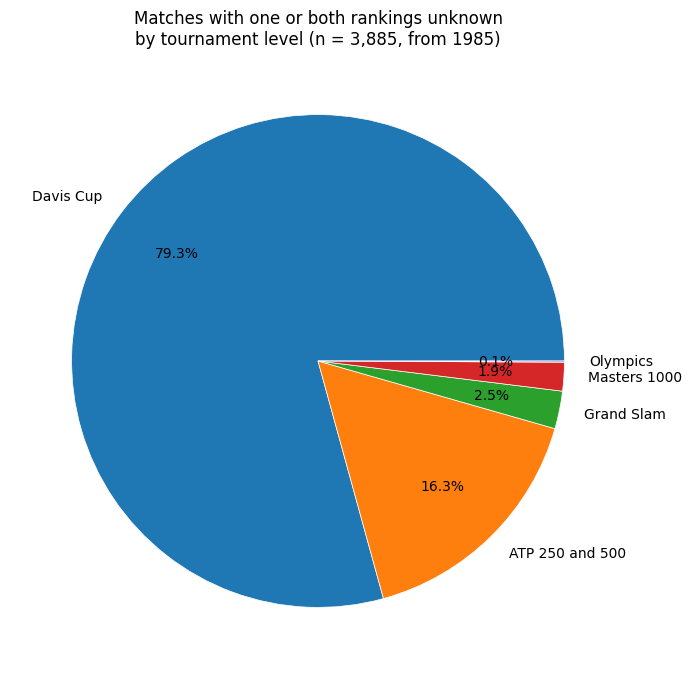

In [232]:
matches_from_1985 = raw_df[raw_df["year"] >= 1985]
one_or_both_unknown = (
    matches_from_1985["player1_rank"].isna()
    | matches_from_1985["player2_rank"].isna()
)
unknown_rank_df = matches_from_1985.loc[one_or_both_unknown]

counts_by_level = unknown_rank_df["tournament_level"].value_counts().sort_values(
    ascending=False
)
labels = [TOURNAMENT_LEVEL_LABELS.get(str(level), str(level)) for level in counts_by_level.index]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    counts_by_level.values,
    labels=labels,
    autopct="%1.1f%%",
    pctdistance=0.72,
    wedgeprops=dict(linewidth=0.5, edgecolor="white"),
)
ax.set_title(
    "Matches with one or both rankings unknown\nby tournament level "
    f"(n = {len(unknown_rank_df):,}, from 1985)"
)
plt.show()

## 4. Data Preparation

### Remove rows with missing features, as specified by `DROP_MISSING_FEATURES`.

In [455]:
n_loaded = len(raw_df)
raw_df = raw_df.dropna(
    subset=DROP_MISSING_FEATURES,
    how="any",
)
n_after_drop = len(raw_df)

(num_rows, num_cols) = raw_df.shape
print(f"Dataset has {num_rows:,} rows and {num_cols} columns.")
print(
    f"Dropped {n_loaded - n_after_drop:,} rows with missing features"
)

Dataset has 189,373 rows and 63 columns.
Dropped 0 rows with missing features


### Feature selection

Metadata features are not used as input (leakage) but remain on the feature matrix.

In [456]:
feature_cols = [c for c in raw_df.columns if c != TARGET_FEATURE and c not in DROP_FEATURES]
X = raw_df[feature_cols].copy()
y = (raw_df[TARGET_FEATURE] == 1).astype(int)

metadata_cols = [c for c in METADATA_FEATURES if c in X.columns]

numeric_features = [
    c
    for c in X.select_dtypes(include=[np.number]).columns
    if c not in METADATA_FEATURES and c not in AS_CATEGORICAL
]
categorical_features = list(AS_CATEGORICAL) + [
    c
    for c in X.select_dtypes(exclude=[np.number]).columns
    if c not in METADATA_FEATURES
]

print(f"Target feature: {TARGET_FEATURE}")
print(f"{len(X.columns)} total features, of which:")
print(f"- {len(metadata_cols)} metadata features: {metadata_cols}")
print(f"- {len(categorical_features)} categorical features: {categorical_features}")
print(f"- {len(numeric_features)} numeric features")

Target feature: winner
62 total features, of which:
- 9 metadata features: ['tournament_id', 'player2_id', 'tournament_start_date', 'player1_id', 'player1_name', 'score', 'tournament_name', 'player2_name', 'match_num']
- 5 categorical features: ['best_of', 'tournament_level', 'surface', 'player1_hand', 'player2_hand']
- 48 numeric features


### Dataset split for training and testing

In [457]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE
)

n = len(X)
print(
    f"Train pool: {len(X_train):,} ({len(X_train) / n:.0%}), "
    f"Hold-out test: {len(X_test):,} ({len(X_test) / n:.0%})"
)

Train pool: 151,498 (80%), Hold-out test: 37,875 (20%)


## 5. Common Training and Testing Infrastructure

### Training and testing approach

**`GridSearchCV`** searches best parameters using **`KFolk`** with **`NUM_CV_SPLITS`** splits with shuffle. Then refit on the full training pool; hold-out test uses **`TEST_RATIO`** of rows.


In [ ]:
def train_model(model_name, estimator, param_grid):
    cv = KFold(n_splits=NUM_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    grid_search = HalvingGridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        refit=True,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    cv_res = grid_search.cv_results_
    n_candidates = len(cv_res["params"])
    fold_x = np.arange(1, NUM_CV_SPLITS + 1)

    fig, ax = plt.subplots(figsize=(14, 6))
    for i in range(n_candidates):
        ys = [cv_res[f"split{j}_test_score"][i] for j in range(NUM_CV_SPLITS)]
        ax.plot(
            fold_x,
            ys,
            marker="o",
            linewidth=1.2,
            alpha=0.85,
            label=f"Parameter set {i}",
        )

    print("\nParameter sets ranked by test score")
    for pos, rank in sorted(enumerate(cv_res["rank_test_score"]), key=lambda x: x[1]):
        params = cv_res["params"][pos]
        score = cv_res["mean_test_score"][pos]
        print(f"#{rank} - Parameter set {pos} with score {score}:\n  {params}")

    ax.set_xlabel("CV fold (test split)")
    ax.set_ylabel(f"Test score ({grid_search.scoring})")
    ax.set_title(
        f"{model_name}: GridSearchCV test score per fold — each line is one parameter set"
    )
    ax.set_xticks(fold_x)
    ax.grid(True, alpha=0.3)
    # ax.legend(loc="best")
    ncol = min(max(n_candidates, 1), 4)

    fig.tight_layout(rect=[0, 0.12 + 0.02 * int(np.ceil(n_candidates / ncol)), 1, 1])
    plt.show()

    print(f"\nGrid search for {model_name} model")
    print(f"\nBest CV score (mean across folds): {grid_search.best_score_:.4f}")
    print(f"Best params: {grid_search.best_params_}")

    return grid_search.best_estimator_, grid_search.cv_results_, grid_search.best_params_

def test_model(model_name, model):
    pred = model.predict(X_test)
    proba_p1 = model.predict_proba(X_test)[:, 1]
    n_correct = int((y_test == pred).sum())
    n_total = len(y_test)
    acc = balanced_accuracy_score(y_test, pred),
    prec = precision_score(y_test, pred, average="weighted")
    rec = recall_score(y_test, pred, average="weighted")
    f1 = f1_score(y_test, pred, average="weighted")
    auc = roc_auc_score(y_test, proba_p1)
    brier = brier_score_loss(y_test, proba_p1)
    logloss = log_loss(y_test, proba_p1)
    print(f"\nTest results for {model_name} model")
    print(
        f"{n_correct:,} / {n_total:,} correct ({n_correct / n_total:.2%}); "
        f"accuracy={acc[0]:.4f}, precision={prec:.4f}, recall={rec:.4f}, F1={f1:.4f}, "
        f"ROC-AUC={auc:.4f}, Brier={brier:.4f}, LogLoss={logloss:.4f}"
    )

def train_and_test_model(model_name, estimator, param_grid):
    trained_model, _, best_params = train_model(model_name, estimator, param_grid)
    test_model(model_name, trained_model)
    return trained_model, best_params

def validate_model(model_name, estimator):
    cv = KFold(n_splits=NUM_CV_SPLITS, shuffle=True)
    fold_metrics = []
    all_predictions = np.zeros(len(y))

    for fold, (cv_train_index, cv_test_index) in enumerate(cv.split(X)):
        X_cv_train, X_cv_test = X.iloc[cv_train_index], X.iloc[cv_test_index]
        y_cv_train, y_cv_test = y.iloc[cv_train_index], y.iloc[cv_test_index]

        # Create a new, unfitted, clone of the estimator and train it
        estimator = clone(estimator).fit(X_cv_train, y_cv_train)
        predictions = estimator.predict(X_cv_test)
        p2_probabilities = estimator.predict_proba(X_cv_test)[:, 1]

        # Store predictions for the full dataset analysis
        all_predictions[cv_test_index] = predictions

        # Calculate and store score for this specific fold
        metrics = {
            "Fold": fold + 1,
            "Accuracy": balanced_accuracy_score(y_cv_test, predictions),
            "Precision": precision_score(y_cv_test, predictions, average="weighted"),
            "Recall": recall_score(y_cv_test, predictions, average="weighted"),
            "F1": f1_score(y_cv_test, predictions, average="weighted"),
            "ROC-AUC": roc_auc_score(y_cv_test, p2_probabilities),
            "Brier": brier_score_loss(y_cv_test, p2_probabilities),
            "LogLoss": log_loss(y_cv_test, p2_probabilities),
        }
        fold_metrics.append(metrics)

    metrics_df = pd.DataFrame(fold_metrics)
    overall_mean = metrics_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Brier", "LogLoss"]].mean()

    print(f"--- Individual Fold Metrics: {model_name} ---")
    print(metrics_df)
    print(f"\n--- Overall Averages: {model_name} ---")
    print(overall_mean)

    feature_plots = [
        ("tournament level", "tournament_level", lambda c: TOURNAMENT_LEVEL_LABELS.get(c, str(c))),
        ("court surface", "surface", lambda c: "unknown" if c is None else str(c)),
        ("match format", "best_of", lambda c: f"best of {str(c)}"),
    ]
    for characteristic, feature_name, label_lambda in feature_plots:
        plot_prediction_accuracy(model_name, all_predictions, characteristic, feature_name, label_lambda)


def plot_prediction_accuracy(model_name, all_predictions, characteristic, feature_name, label_lambda):
    # Line chart: accuracy (%) vs calendar year; one line per tournament level (CV predictions)
    year_series = pd.to_datetime(X["tournament_start_date"], errors="coerce").dt.year
    labels = X[feature_name].astype(str).map(label_lambda)
    y_arr = np.asarray(y)
    correct = all_predictions == y_arr
    val_df = pd.DataFrame(
        {"year": year_series, "label": labels, "correct": correct}
    ).dropna(subset=["year"])
    acc_pct = (
        val_df.groupby(["year", "label"], observed=True)["correct"]
        .mean()
        .mul(100)
        .unstack("label")
    )
    acc_pct_overall = (
        val_df.groupby("year", observed=True)["correct"].mean().mul(100)
    )

    _fig, ax = plt.subplots(figsize=(14, 6))
    for col in acc_pct.columns:
        ax.plot(
            acc_pct.index,
            acc_pct[col],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=str(col),
        )
    ax.plot(
        acc_pct_overall.index,
        acc_pct_overall.values,
        color="black",
        linewidth=2.5,
        linestyle="-",
        marker="D",
        markersize=4,
        label="Overall",
        zorder=10,
    )
    ax.set_xlabel("Year")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(
        f"{model_name}: prediction accuracy by {characteristic} (out-of-fold CV)"
    )
    # ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


def shap_analysis(pipeline):
    # Extract the fitted model from the pipeline
    model = pipeline.named_steps['model']
    prep = pipeline.named_steps['prep']

    # Extract the preprocessing steps to transform the data
    X_test_transformed = prep.transform(X_test)

    # Get the feature names
    feature_names = prep.get_feature_names_out()

    # Convert back to a DataFrame so SHAP has column names
    X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

    # Initialize TreeExplainer with the extracted model
    explainer = shap.TreeExplainer(model, X_test_df)
    explanation = explainer(X_test_df)

    # Plots
    shap.plots.bar(explanation, max_display=60)
    shap.plots.beeswarm(explanation, max_display=30)

## 5. Models

### Random Forest

n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 50499
max_resources_: 151498
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 4
n_resources: 50499
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 1
n_candidates: 2
n_resources: 151497
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Parameter sets ranked by test score
#1 - Parameter set 4 with score 0.696150996888448:
  {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}
#2 - Parameter set 5 with score 0.6960585808939059:
  {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}
#3 - Parameter set 1 with score 0.6954946034260818:
  {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__ra

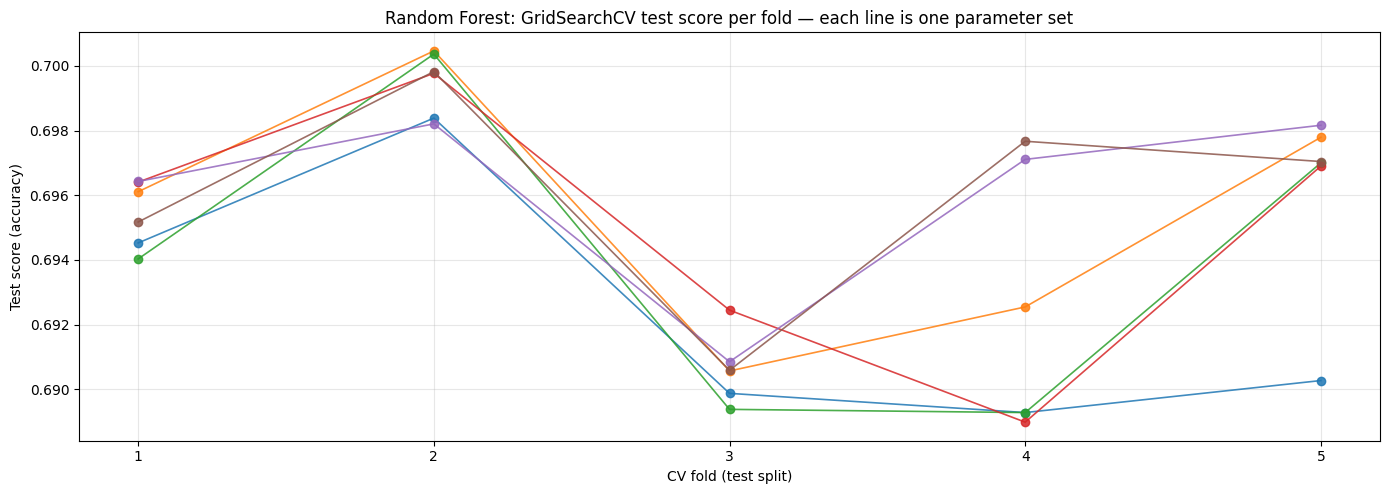


Grid search for Random Forest model

Best CV score (mean across folds): 0.6962
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 4, 'model__n_estimators': 200, 'model__random_state': 42}

Test results for Random Forest model
26,326 / 37,875 correct (69.51%); accuracy=0.6951, precision=0.6951, recall=0.6951, F1=0.6951, ROC-AUC=0.7674


In [497]:
RF_MODEL_NAME = "Random Forest"

# RandomForest hyperparameters for GridSearchCV (pipeline step name: "model")
RF_PARAM_GRID = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [2, 4],
    "model__random_state": [RANDOM_STATE],
    "model__class_weight": ["balanced"],
}

_transformers = []
if metadata_cols:
    _transformers.append(("drop_metadata", "drop", metadata_cols))
_transformers.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers.append(
        (
            "cat",
            Pipeline(
                steps=[
                    # ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor = ColumnTransformer(transformers=_transformers)

rf_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        (
            "model",
            RandomForestClassifier(),
        ),
    ]
)

trained_rf, best_rf_params = train_and_test_model(RF_MODEL_NAME, rf_pipeline, RF_PARAM_GRID)


--- Individual Fold Metrics: Random Forest ---
   Fold  Accuracy  Precision    Recall        F1   ROC-AUC     Brier   LogLoss
0     1  0.701026   0.701043  0.701043  0.701037  0.772586  0.194114  0.569268
1     2  0.693192   0.693208  0.693201  0.693194  0.767921  0.195725  0.572627
2     3  0.695261   0.695261  0.695261  0.695261  0.768743  0.195521  0.572753
3     4  0.698684   0.698692  0.698685  0.698682  0.771225  0.194570  0.570326
4     5  0.694987   0.694993  0.694989  0.694986  0.768076  0.195786  0.573282

--- Overall Averages: Random Forest ---
Accuracy     0.696630
Precision    0.696639
Recall       0.696636
F1           0.696632
ROC-AUC      0.769710
Brier        0.195143
LogLoss      0.571651
dtype: float64


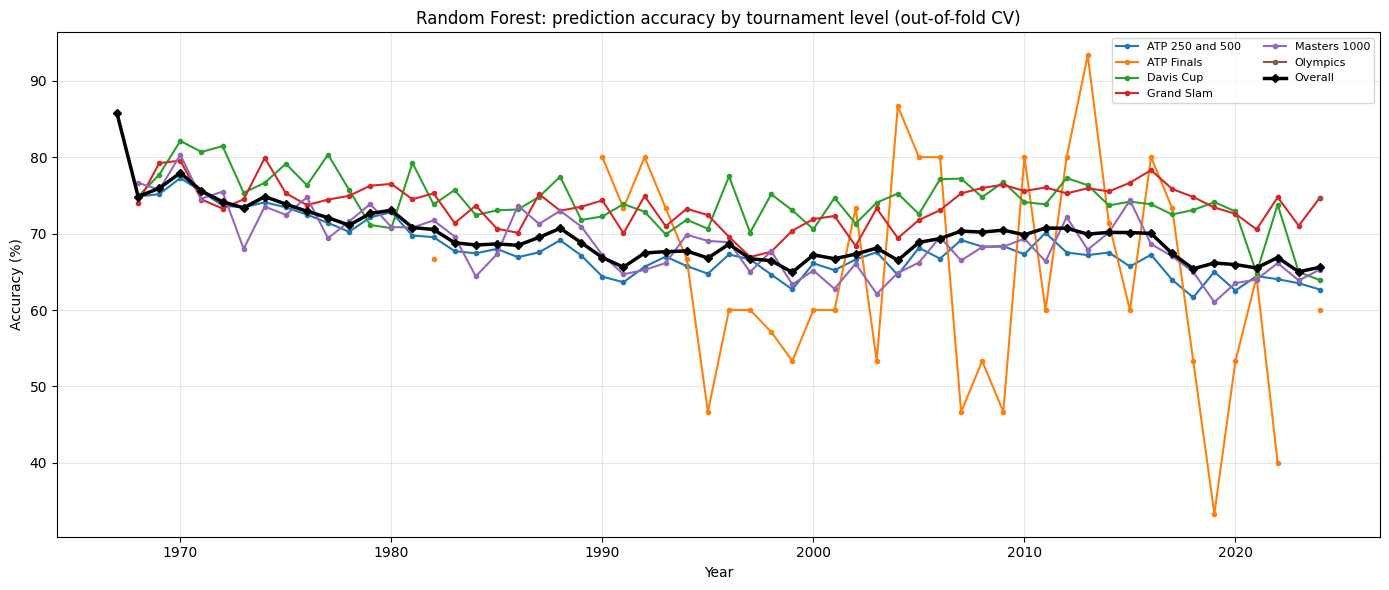

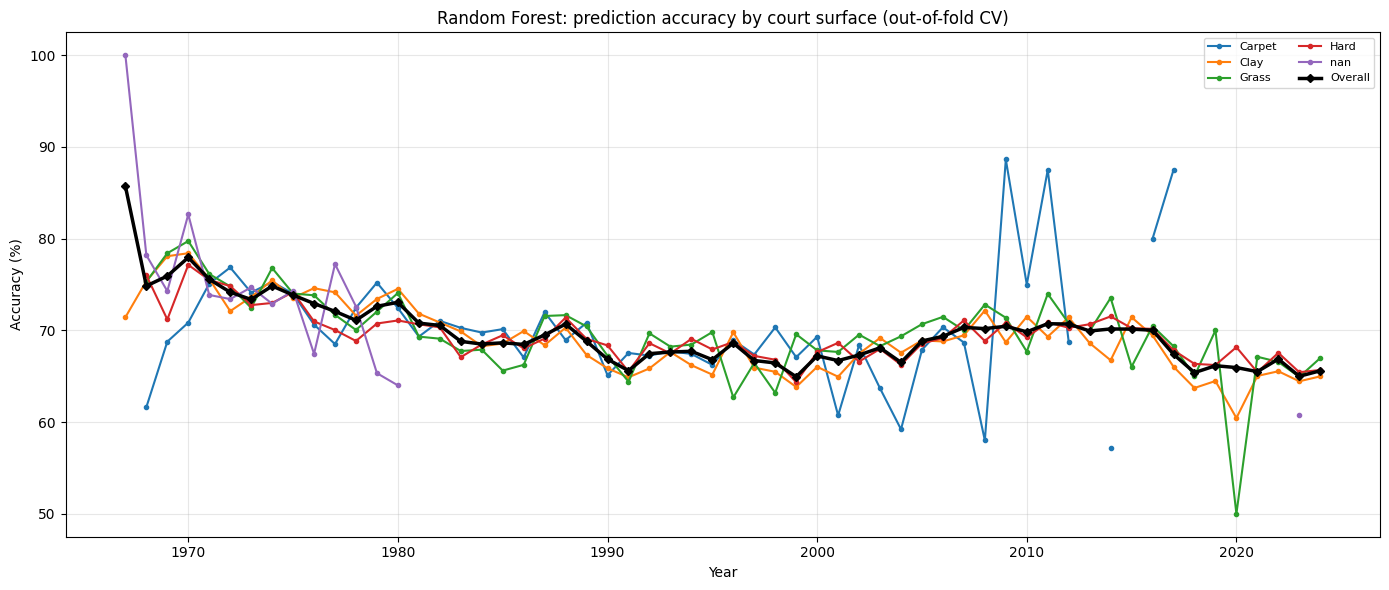

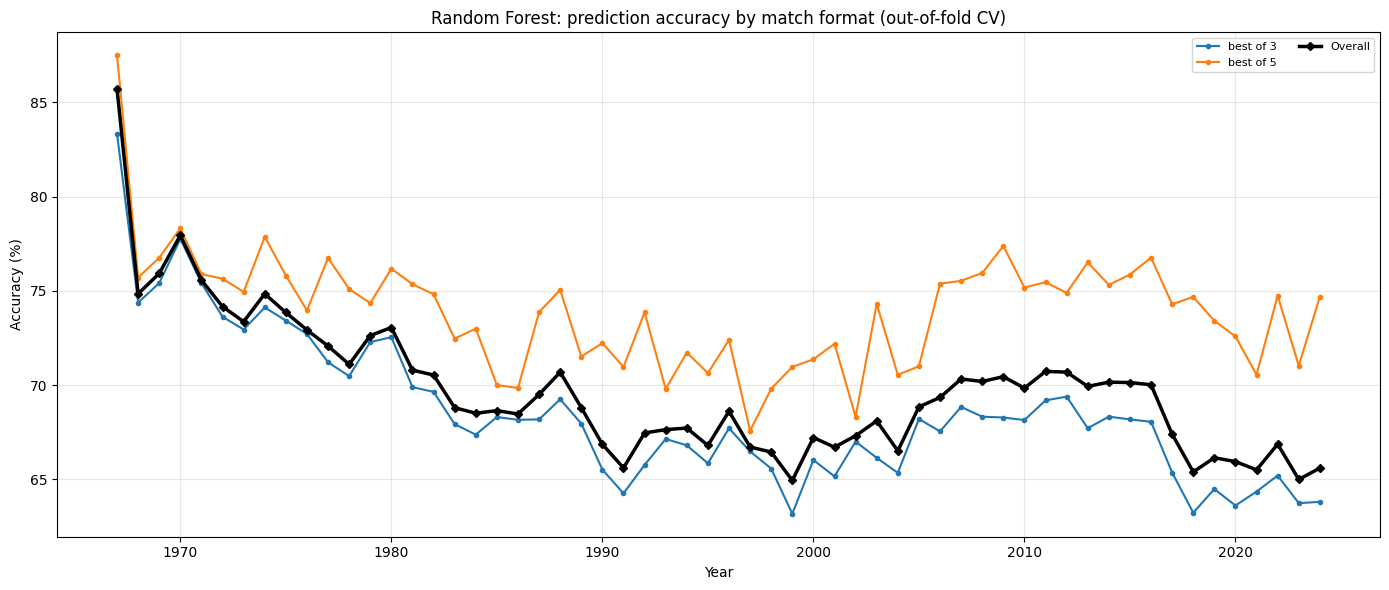

In [514]:
validate_model(RF_MODEL_NAME, trained_rf)

### XGBoost (eXtreme Gradient Boosting)

n_iterations: 5
n_required_iterations: 6
n_possible_iterations: 5
min_resources_: 623
max_resources_: 151498
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 320
n_resources: 623
Fitting 5 folds for each of 320 candidates, totalling 1600 fits


----------
iter: 1
n_candidates: 107
n_resources: 1869
Fitting 5 folds for each of 107 candidates, totalling 535 fits
----------
iter: 2
n_candidates: 36
n_resources: 5607
Fitting 5 folds for each of 36 candidates, totalling 180 fits
----------
iter: 3
n_candidates: 12
n_resources: 16821
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 4
n_candidates: 4
n_resources: 50463
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Parameter sets ranked by test score
#1 - Parameter set 402 with score 0.7067024128686328:
  {'model__colsample_bytree': 0.8, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.01, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__n_jobs': -1, 'model__random_state': 42, 'model__subsample': 1.0, 'model__tree_method': 'hist'}
#2 - Parameter set 394 with score 0.7061662198391422:
  {'model__colsample_bytree': 1.0, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.02, 'model__max_depth': 4, 'model__n_estimato

/var/folders/6v/wpxlz5q55kb7cr5cswv0274h0000gp/T/ipykernel_6720/513791775.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0.12 + 0.02 * int(np.ceil(n_candidates / ncol)), 1, 1])


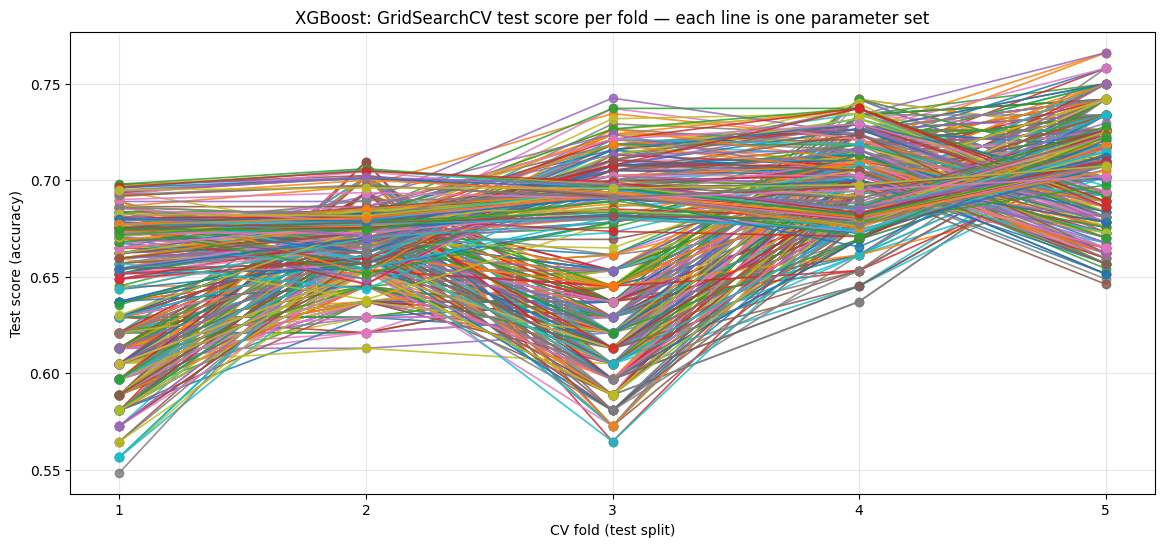


Grid search for XGBoost model

Best CV score (mean across folds): 0.6984
Best params: {'model__colsample_bytree': 0.8, 'model__eval_metric': 'logloss', 'model__learning_rate': 0.02, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__n_jobs': -1, 'model__random_state': 42, 'model__subsample': 0.8, 'model__tree_method': 'hist'}

Test results for XGBoost model
26,435 / 37,875 correct (69.80%); accuracy=0.6980, precision=0.6980, recall=0.6980, F1=0.6980, ROC-AUC=0.7697


In [515]:
XGB_MODEL_NAME = "XGBoost"

XGB_PARAM_GRID = {
    "model__n_estimators": [200, 300, 400, 500, 600],
    "model__max_depth": [2, 4, 6, 8],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__random_state": [RANDOM_STATE],
    "model__n_jobs": [-1],
    "model__eval_metric": ["logloss"],
    "model__tree_method": ["hist"],
}

_transformers_xgb = []
if metadata_cols:
    _transformers_xgb.append(("drop_metadata", "drop", metadata_cols))
_transformers_xgb.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers_xgb.append(
        (
            "cat",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor_xgb = ColumnTransformer(transformers=_transformers_xgb)

xgb_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor_xgb),
        ("model", XGBClassifier()),
    ]
)

trained_xgb, best_xgb_params = train_and_test_model(XGB_MODEL_NAME, xgb_pipeline, XGB_PARAM_GRID)

--- Individual Fold Metrics: XGBoost ---
   Fold  Accuracy  Precision    Recall        F1   ROC-AUC     Brier   LogLoss
0     1  0.694309   0.694315  0.694310  0.694311  0.767237  0.196219  0.574561
1     2  0.698370   0.698390  0.698350  0.698351  0.769848  0.195305  0.572731
2     3  0.694743   0.694758  0.694733  0.694736  0.765727  0.196817  0.575984
3     4  0.701905   0.701955  0.701854  0.701859  0.772423  0.194341  0.570582
4     5  0.697645   0.697654  0.697655  0.697653  0.770860  0.194846  0.571257

--- Overall Averages: XGBoost ---
Accuracy     0.697394
Precision    0.697414
Recall       0.697380
F1           0.697382
ROC-AUC      0.769219
Brier        0.195505
LogLoss      0.573023
dtype: float64


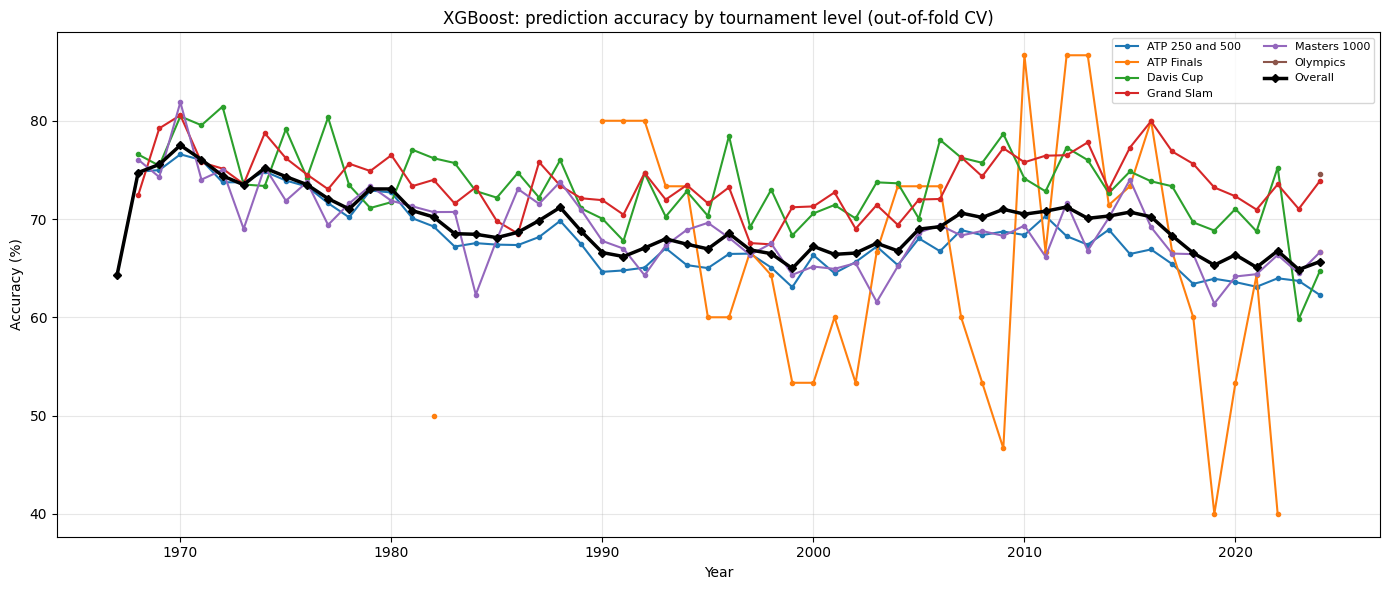

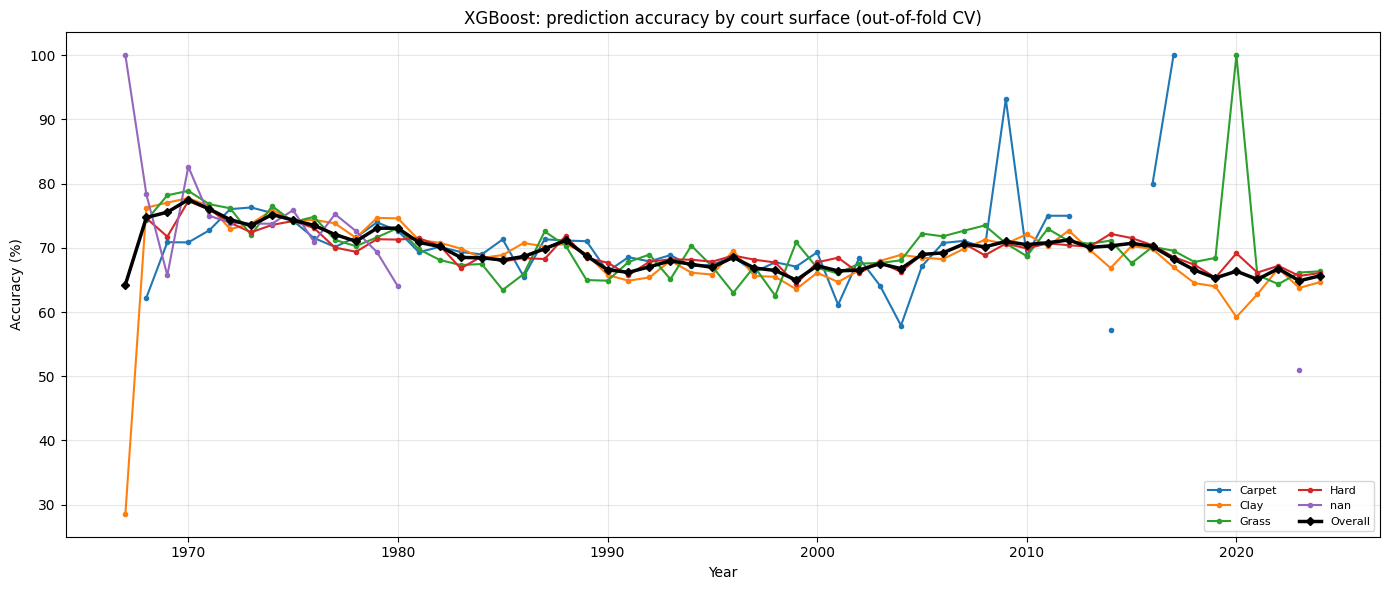

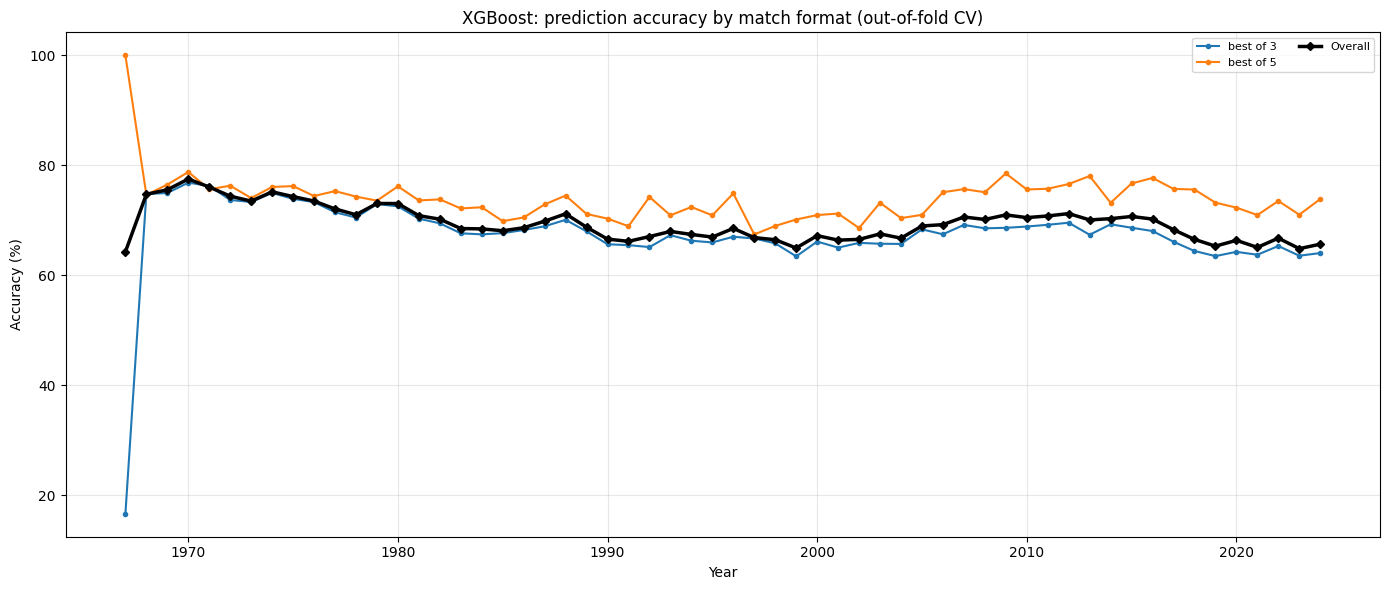

In [512]:
validate_model(XGB_MODEL_NAME, trained_xgb)


### CatBoost

**`verbose=False`** and **`allow_writing_files=False`** keep runs quiet in the notebook.

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 16833
max_resources_: 151498
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 18
n_resources: 16833
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 6
n_resources: 50499
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 2
n_candidates: 2
n_resources: 151497
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Parameter sets ranked by test score
#1 - Parameter set 3 with score 0.7026737967914438:
  {'model__allow_writing_files': False, 'model__depth': 6, 'model__iterations': 1000, 'model__learning_rate': 0.01, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': -1, 'model__verbose': False}
#2 - Parameter set 6 with score 0.7023767082590612:
  {'model__allow_writing_files': False, 'model__depth': 8, 'model__iterations': 800, 'model__learning_rate': 0.01, 'model__loss_funct

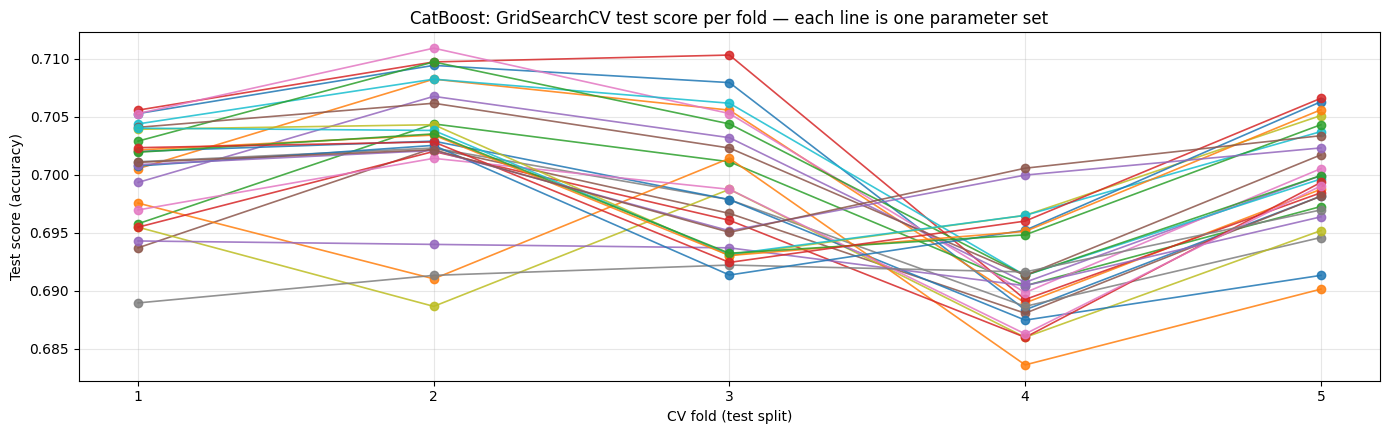


Grid search for CatBoost model

Best CV score (mean across folds): 0.7004
Best params: {'model__allow_writing_files': False, 'model__depth': 10, 'model__iterations': 1000, 'model__learning_rate': 0.01, 'model__loss_function': 'Logloss', 'model__random_state': 42, 'model__thread_count': -1, 'model__verbose': False}

Test results for CatBoost model
26,497 / 37,875 correct (69.96%); accuracy=0.6996, precision=0.6996, recall=0.6996, F1=0.6996, ROC-AUC=0.7733


In [496]:
CATB_MODEL_NAME = "CatBoost"

CATB_PARAM_GRID = {
    "model__iterations": [800, 1000],
    "model__depth": [6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__random_state": [RANDOM_STATE],
    "model__verbose": [False],
    "model__loss_function": ["Logloss"],
    "model__allow_writing_files": [False],
    "model__thread_count": [-1],
}

_transformers_catb = []
if metadata_cols:
    _transformers_catb.append(("drop_metadata", "drop", metadata_cols))
_transformers_catb.append(("num", SimpleImputer(strategy="median"), numeric_features))
if categorical_features:
    _transformers_catb.append(
        (
            "cat",
            Pipeline(
                steps=[
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            categorical_features,
        )
    )

preprocessor_catb = ColumnTransformer(transformers=_transformers_catb)

catb_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor_catb),
        ("model", CatBoostClassifier()),
    ]
)

trained_catb, best_catb_params = train_and_test_model(CATB_MODEL_NAME, catb_pipeline, CATB_PARAM_GRID)

--- Individual Fold Metrics: CatBoost ---
   Fold  Accuracy  Precision    Recall        F1   ROC-AUC     Brier   LogLoss
0     1  0.700148   0.700178  0.700145  0.700135  0.774101  0.193251  0.566401
1     2  0.700277   0.700284  0.700277  0.700279  0.773222  0.193678  0.567805
2     3  0.702971   0.702971  0.702970  0.702970  0.778205  0.191680  0.562934
3     4  0.704726   0.704738  0.704731  0.704727  0.777048  0.192206  0.564356
4     5  0.698320   0.698345  0.698342  0.698343  0.773532  0.193385  0.566457

--- Overall Averages: CatBoost ---
Accuracy     0.701288
Precision    0.701303
Recall       0.701293
F1           0.701291
ROC-AUC      0.775222
Brier        0.192840
LogLoss      0.565591
dtype: float64


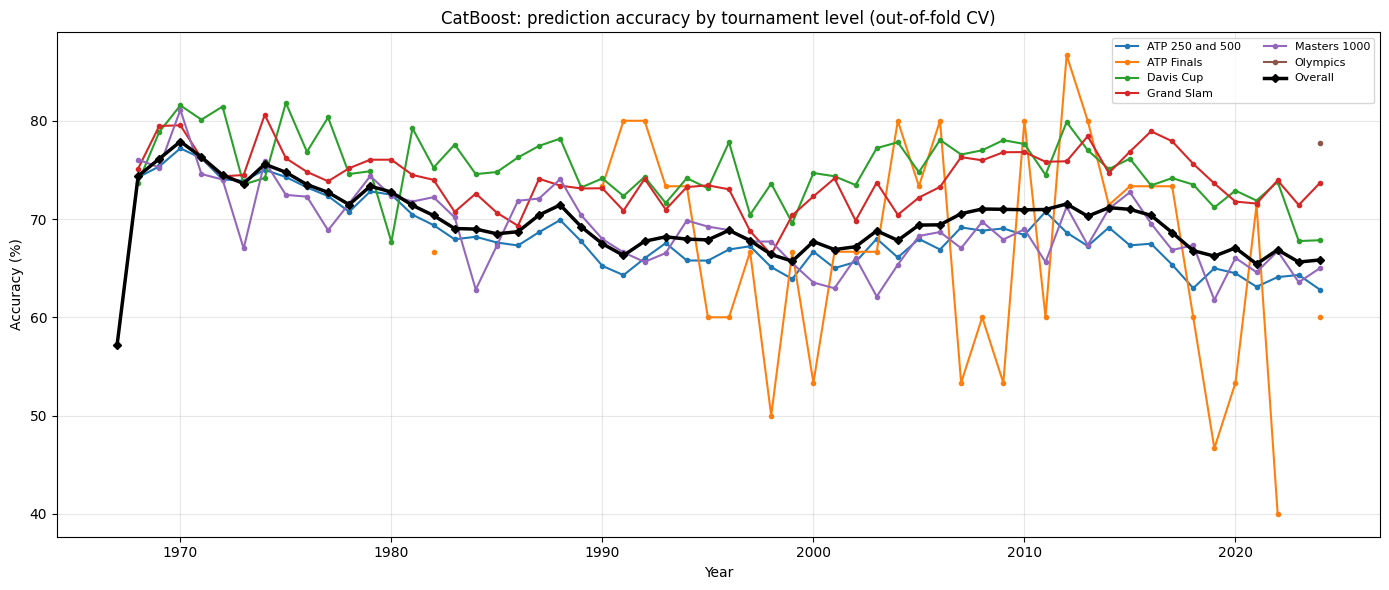

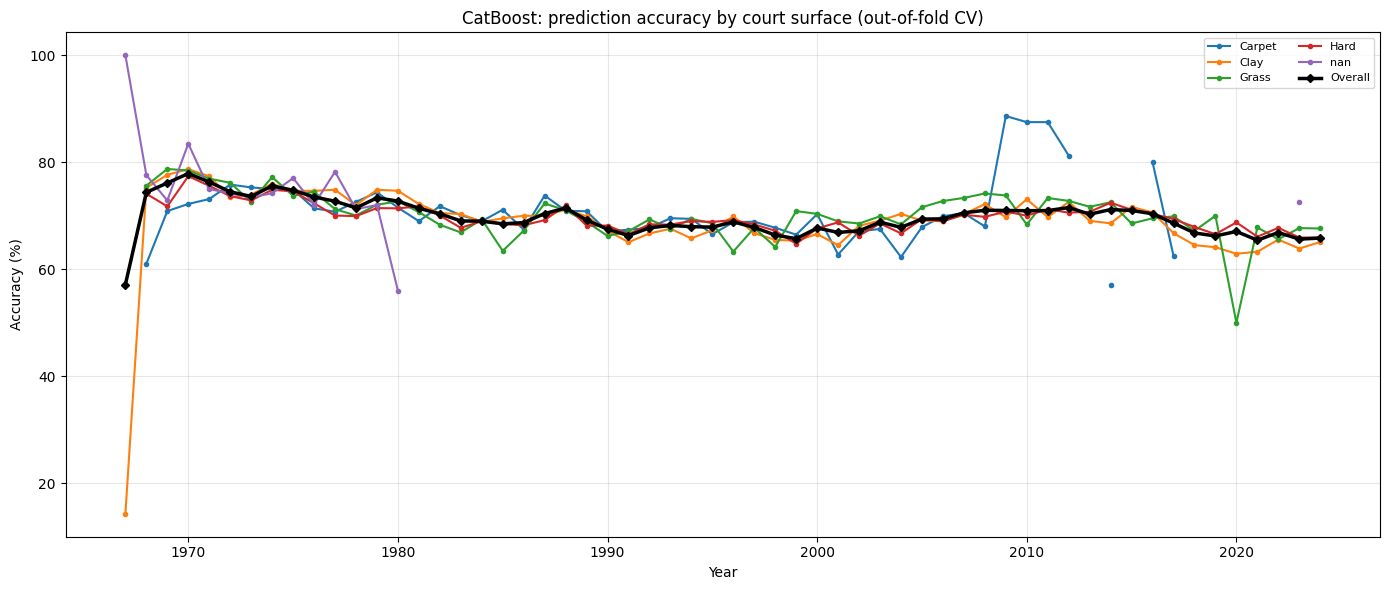

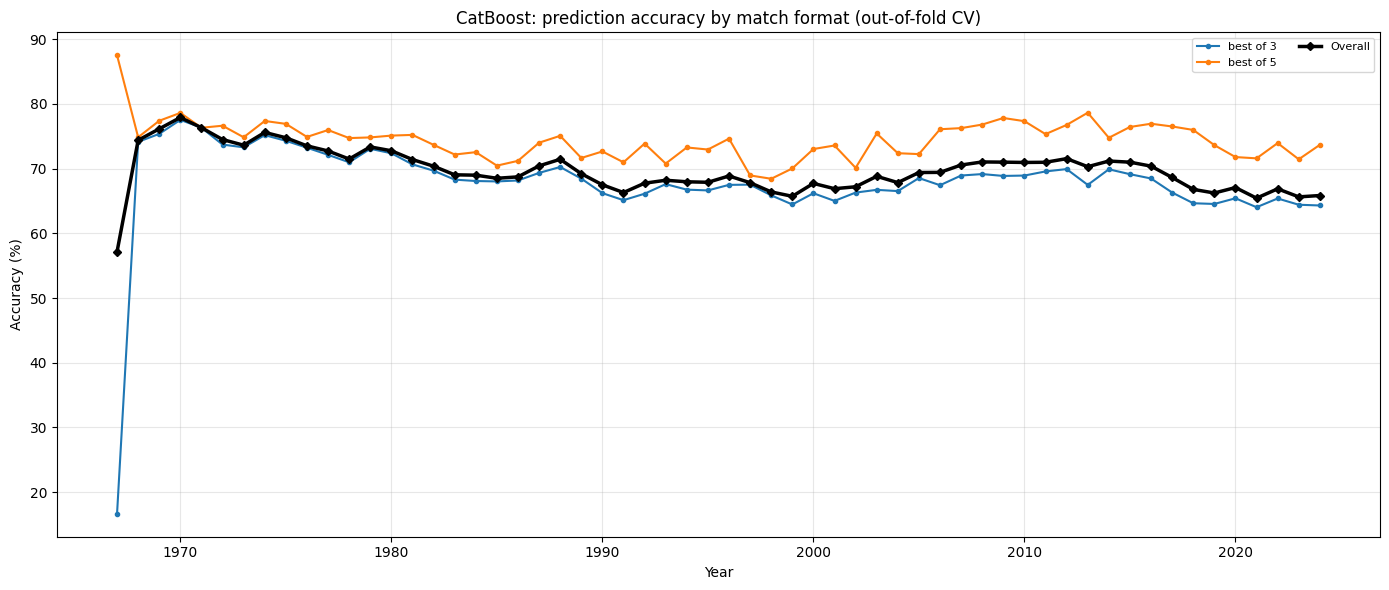

In [513]:
validate_model(CATB_MODEL_NAME, trained_catb)


# 6. Analysis

## Prediction accuracy over years

Using the held-out test set, compute the average accuracy per calendar year for the best-tuned XGBoost pipeline and show the results alongside the number of test samples per year. This chart excludes 1967 as it only has 14 matches.

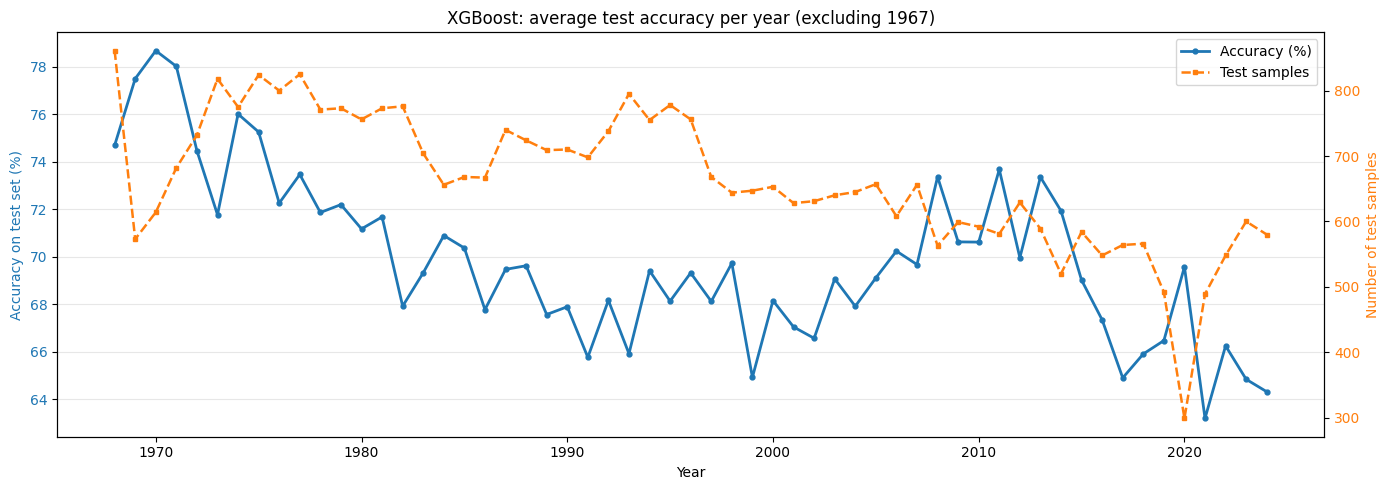

In [284]:
# XGBoost test accuracy by year


year_test = pd.to_datetime(X_test["tournament_start_date"], errors="coerce").dt.year
mask_year = year_test.notna() & (year_test > 1967)

y_pred_xgb = xgb_model.predict(X_test)
correct_xgb = (y_pred_xgb == np.asarray(y_test))

by_year = pd.DataFrame(
    {
        "year": year_test[mask_year].astype(int),
        "correct": correct_xgb[mask_year.to_numpy()],
    }
)

acc_by_year_xgb = by_year.groupby("year", observed=True)["correct"].mean() * 100
n_by_year_xgb = by_year.groupby("year", observed=True)["correct"].size()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    acc_by_year_xgb.index,
    acc_by_year_xgb.values,
    linewidth=2.0,
    marker="o",
    markersize=3.5,
    color="#1f77b4",
    label="Accuracy (%)",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Accuracy on test set (%)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.3, axis="y")

ax2 = ax1.twinx()
ax2.plot(
    n_by_year_xgb.index,
    n_by_year_xgb.values,
    linewidth=1.8,
    marker="s",
    markersize=3.0,
    color="#ff7f0e",
    linestyle="--",
    label="Test samples",
)
ax2.set_ylabel("Number of test samples", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")

ax1.set_title("XGBoost: average test accuracy per year (excluding 1967)")

lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

plt.tight_layout()
plt.show()

## SHapley Additive exPlanations

100%|===================| 37871/37875 [03:53<00:00]        

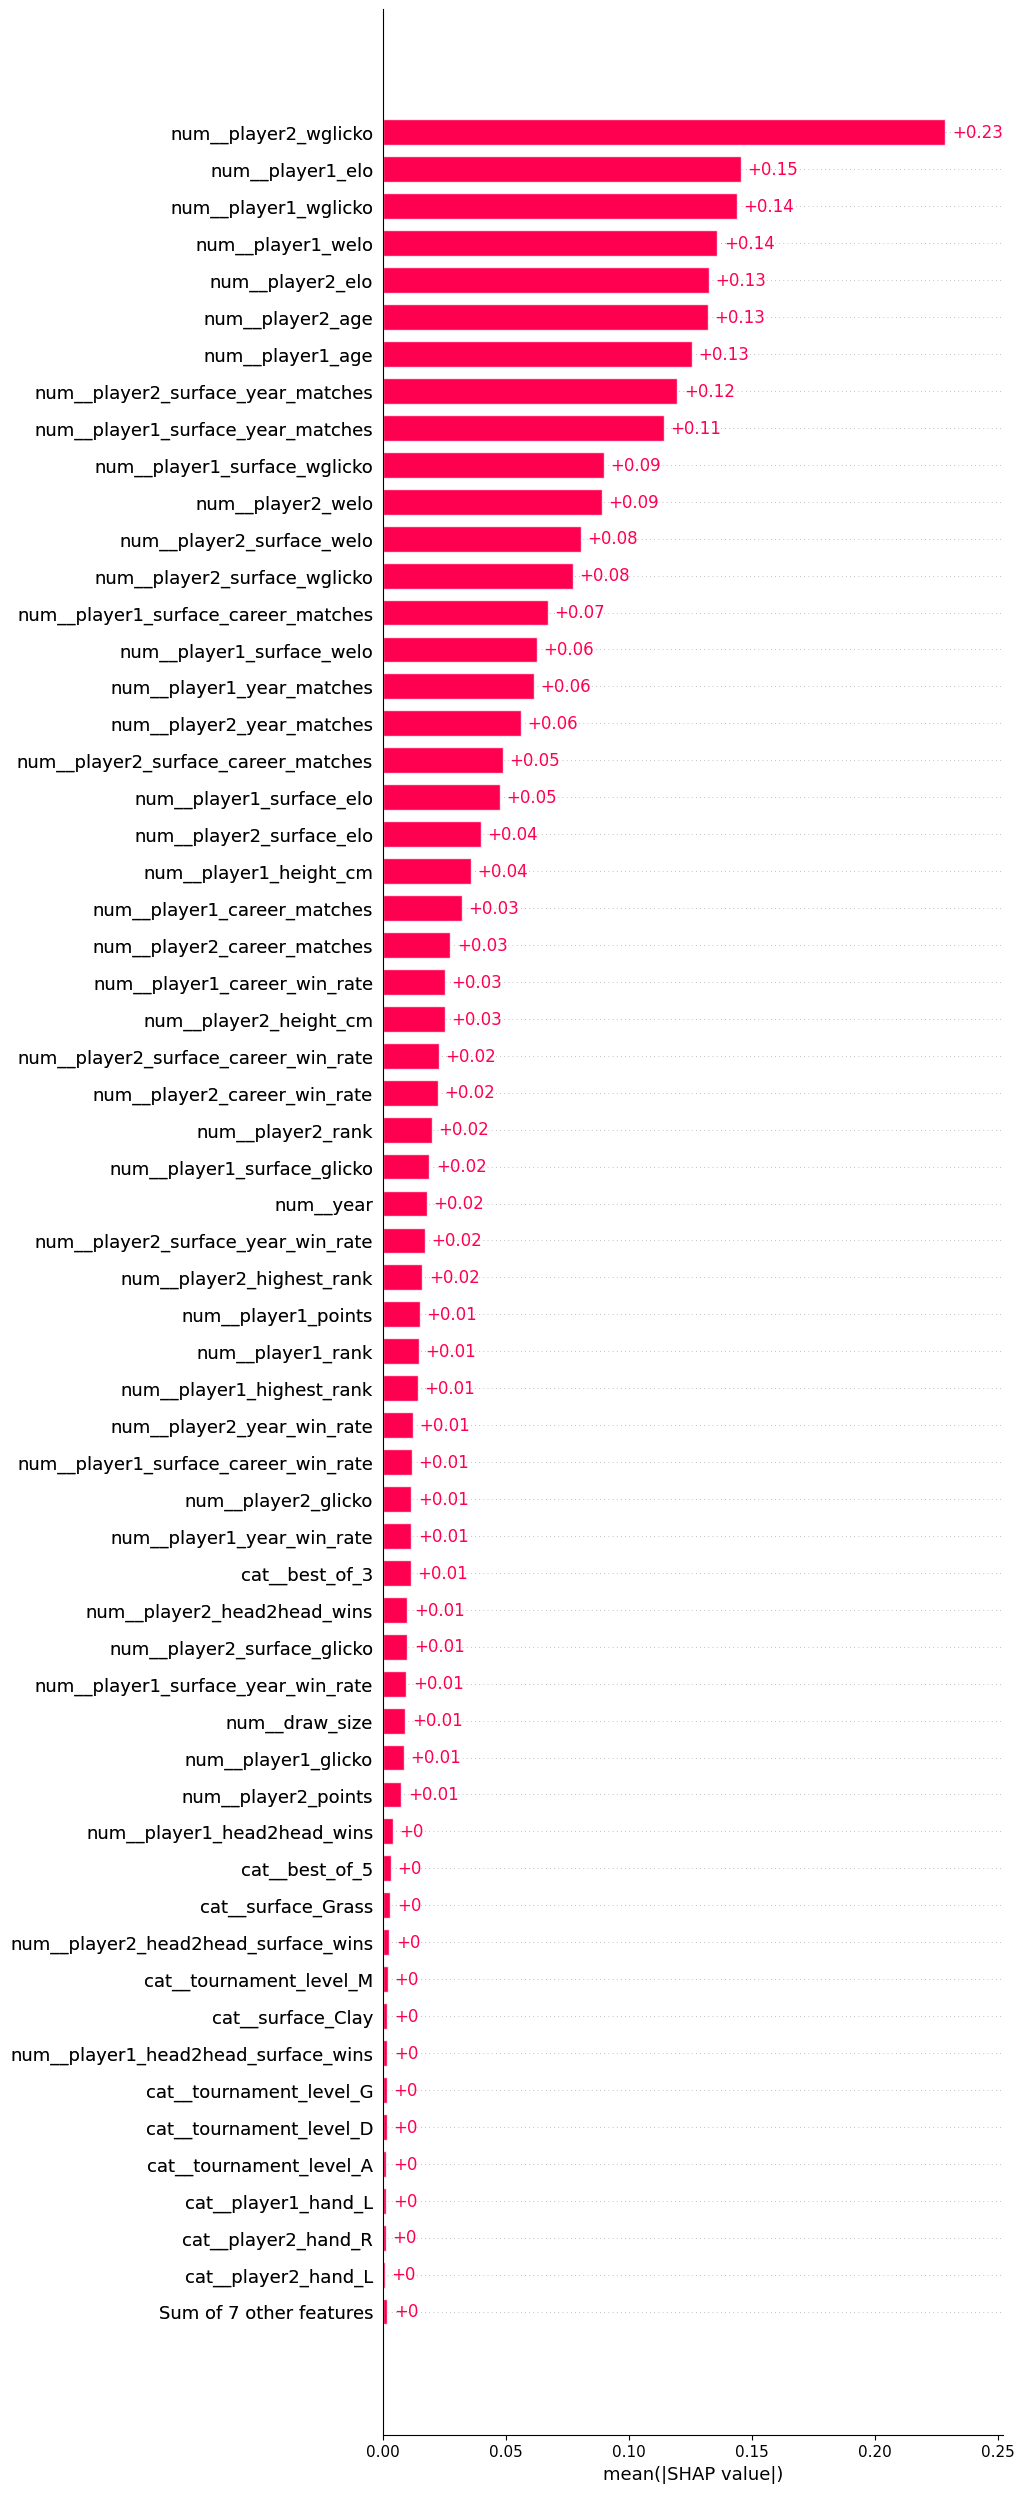

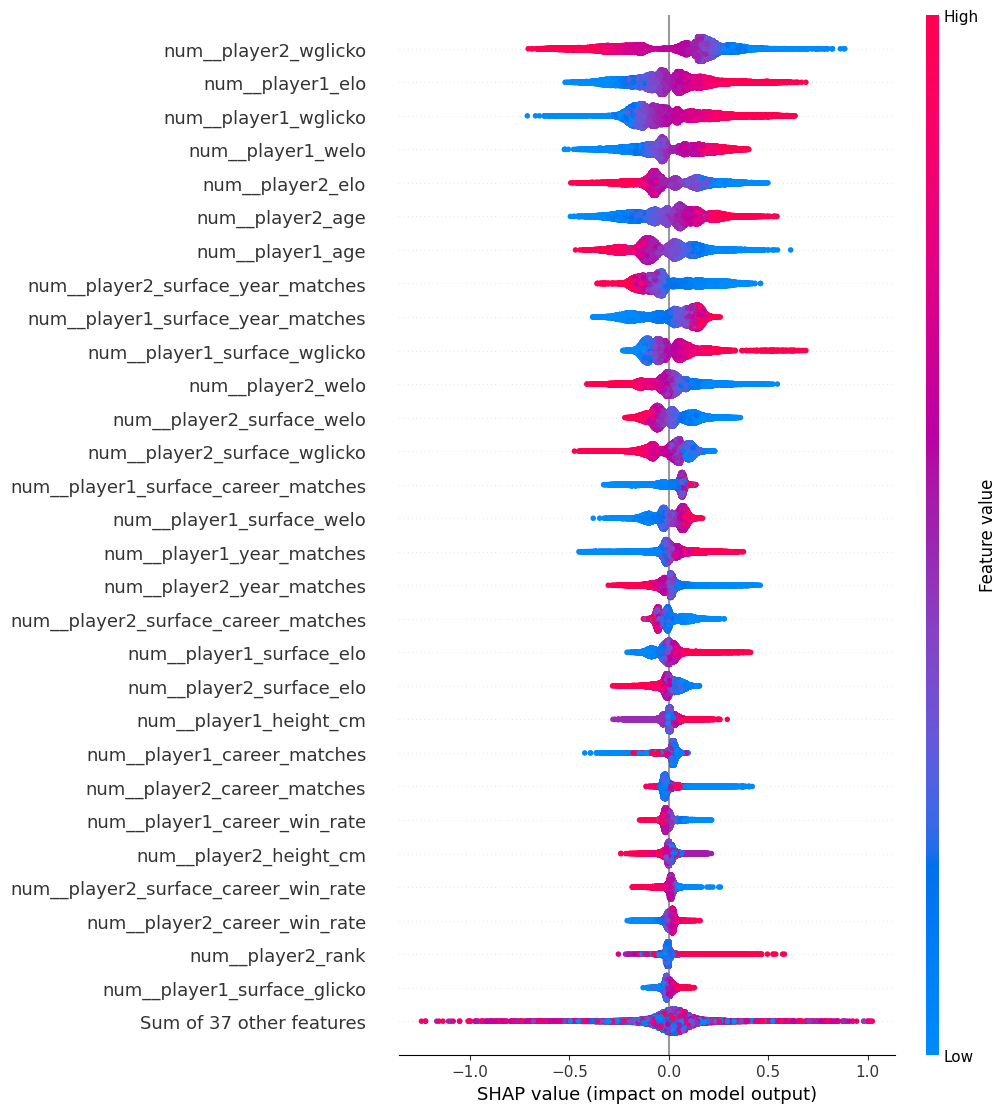

In [285]:
shap_analysis(xgb_model)